# Laboratorio 6: método de elementos finitos en 1D

**Andrés Felipe Serrano Barrios**

Física Computacional I (0302151), grupo 001

Instituto de Física, Universidad de Antioquia

Semestre 2026-2, profesor Andrés Felipe Rivera Romero

---

# 1. Forma débil

Problema general, con $f$ continua en $[a,b]$:

$$-\frac{d^2y}{dx^2}=f(x),\qquad a\le x\le b,\qquad y(a)=y_a,\quad y(b)=y_b.$$

En este laboratorio $f(x)=x\,e^x$, $[a,b]=[0,1]$, $y_a=3-e$ y $y_b=0$.

**Paso 1. Función de prueba.** Se multiplica por una función $\Phi$ con $\Phi(a)=\Phi(b)=0$ y se
integra en $[a,b]$:

$$-\int_a^b y''\,\Phi\,dx=\int_a^b f\,\Phi\,dx.$$

**Paso 2. Integración por partes.** Con $u=\Phi$ y $dv=y''\,dx$:

$$-\int_a^b y''\,\Phi\,dx=-\Big[\,y'\,\Phi\,\Big]_a^b+\int_a^b y'\,\Phi'\,dx=\int_a^b y'\,\Phi'\,dx,$$

porque $\Phi$ se anula en los extremos. La forma débil es

$$\int_a^b y'\,\Phi'\,dx=\int_a^b f\,\Phi\,dx.\tag{1}$$

---

# 2. Funciones sombrero y matriz de rigidez

Malla uniforme con $N$ elementos: $h=(b-a)/N$ y $x_i=a+i\,h$, con $i=0,1,\dots,N$. El elemento $e$ es
el intervalo $[x_e,x_{e+1}]$.

**Paso 3. Funciones sombrero.**

$$\phi_i(x)=\begin{cases}\dfrac{x-x_{i-1}}{h}, & x_{i-1}\le x\le x_i,\\[8pt]
\dfrac{x_{i+1}-x}{h}, & x_i\le x\le x_{i+1},\\[8pt] 0, & \text{fuera de }[x_{i-1},x_{i+1}],\end{cases}
\qquad
\phi_i'(x)=\begin{cases}\dfrac{1}{h}, & x_{i-1}<x<x_i,\\[8pt] -\dfrac{1}{h}, & x_i<x<x_{i+1},\\[8pt]
0, & \text{fuera de }[x_{i-1},x_{i+1}].\end{cases}$$

$\phi_i(x_i)=1$ y $\phi_i(x_j)=0$ en los demás nodos.

**Paso 4. Aproximación.**

$$y_h(x)=\sum_{j=0}^{N}y_j\,\phi_j(x),\qquad y_h(x_i)=y_i,$$

con $y_0=y_a$ y $y_N=y_b$ conocidos. Entre dos nodos, $y_h$ es la recta que los une. Con $\Phi=\phi_i$,
$i=1,\dots,N-1$, que se anulan en $a$ y en $b$, la ecuación (1) se convierte en

$$\sum_{j=0}^{N}A_{ij}\,y_j=b_i,\qquad A_{ij}=\int_a^b\phi_i'\,\phi_j'\,dx,\qquad b_i=\int_a^b f\,\phi_i\,dx.$$

**Paso 5. Matriz de cada elemento.** En el elemento $e$ solo $\phi_e$ y $\phi_{e+1}$ son distintas de
cero, con derivadas $-1/h$ y $1/h$:

$$\int_{x_e}^{x_{e+1}}(\phi_e')^2\,dx=\int_{x_e}^{x_{e+1}}(\phi_{e+1}')^2\,dx=\frac{1}{h},\qquad
\int_{x_e}^{x_{e+1}}\phi_e'\,\phi_{e+1}'\,dx=-\frac{1}{h}.$$

El nodo $i$ pertenece a los elementos $i-1$ e $i$; al sumar las contribuciones de ambos,

$$A_{i,i}=\frac{2}{h},\qquad A_{i,i-1}=A_{i,i+1}=-\frac{1}{h},$$

y los demás elementos de $A$ son nulos, porque los soportes de $\phi_i$ y $\phi_j$ no se superponen si
$|i-j|>1$.

**Paso 6. Condiciones de Dirichlet.** En las filas $i=1$ e $i=N-1$ aparecen los valores conocidos
$y_0=y_a$ y $y_N=y_b$, que se trasladan al lado derecho:

$$-\frac{1}{h}\,y_a+\frac{2}{h}\,y_1-\frac{1}{h}\,y_2=b_1
\quad\Rightarrow\quad\frac{2}{h}\,y_1-\frac{1}{h}\,y_2=b_1+\frac{y_a}{h},$$

y de forma análoga con $y_b$ en la fila $N-1$. El sistema resultante tiene $N-1$ incógnitas:

$$\frac{1}{h}\begin{pmatrix}2&-1&&&\\-1&2&-1&&\\&\ddots&\ddots&\ddots&\\&&-1&2&-1\\&&&-1&2\end{pmatrix}
\begin{pmatrix}y_1\\y_2\\\vdots\\y_{N-2}\\y_{N-1}\end{pmatrix}
=\begin{pmatrix}b_1+y_a/h\\b_2\\\vdots\\b_{N-2}\\b_{N-1}+y_b/h\end{pmatrix}.\tag{2}$$

---

# 3. Vector de carga

**Paso 7. Aporte de cada elemento.** $b_i$ recibe contribuciones de los elementos $i-1$ e $i$. El
elemento $e$ contribuye a $b_e$ y a $b_{e+1}$ con

$$\int_{x_e}^{x_{e+1}}f\,\phi_e\,dx\qquad\text{y}\qquad\int_{x_e}^{x_{e+1}}f\,\phi_{e+1}\,dx.$$

**Paso 8. Coordenada local.** Con $x_c=\dfrac{x_e+x_{e+1}}{2}$, $x=x_c+\dfrac{h}{2}\,t$ y $-1\le t\le1$:

$$\phi_e=\frac{x_{e+1}-x}{h}=\frac{1-t}{2},\qquad\phi_{e+1}=\frac{x-x_e}{h}=\frac{1+t}{2},\qquad
dx=\frac{h}{2}\,dt,$$

$$\int_{x_e}^{x_{e+1}}f\,\phi_e\,dx=\frac{h}{2}\int_{-1}^{1}f\!\left(x_c+\frac{h}{2}\,t\right)\frac{1-t}{2}\,dt,
\qquad
\int_{x_e}^{x_{e+1}}f\,\phi_{e+1}\,dx=\frac{h}{2}\int_{-1}^{1}f\!\left(x_c+\frac{h}{2}\,t\right)\frac{1+t}{2}\,dt.$$

**Paso 9. Cuadratura de Gauss con tres puntos.** El código de clase calcula estas integrales con
`integrate.quad`. En su lugar se usa la cuadratura gaussiana de la
[sesión 3.1](https://github.com/anferivera/Fisica_Computacional_1/blob/main/Sesiones/PDE/3.1_FEM_finite_element_method.ipynb) con $n=3$, cuyos pesos y puntos se obtienen exigiendo que

$$\int_{-1}^{1}g(t)\,dt\approx w_1\,g(-c)+w_0\,g(0)+w_1\,g(c)$$

sea exacta para $g=1,t,t^2,\dots,t^5$. Con puntos simétricos, las potencias impares se anulan en ambos
lados; las pares imponen

$$g=1:\ \ 2w_1+w_0=2,\qquad g=t^2:\ \ 2w_1\,c^2=\frac{2}{3},\qquad g=t^4:\ \ 2w_1\,c^4=\frac{2}{5}.$$

Dividiendo la tercera por la segunda, $c^2=3/5$; de la segunda, $w_1=\dfrac{1}{3c^2}=\dfrac{5}{9}$, y de
la primera, $w_0=2-2w_1=\dfrac{8}{9}$:

$$\int_{-1}^{1}g(t)\,dt\approx\frac{5}{9}\,g\!\left(-\sqrt{3/5}\right)+\frac{8}{9}\,g(0)
+\frac{5}{9}\,g\!\left(\sqrt{3/5}\right).$$

---

# 4. Solución del sistema tridiagonal

**Paso 10. Algoritmo de Thomas.** El código de clase resuelve el sistema con `np.linalg.solve` sobre la
matriz completa. Como la matriz de (2) es tridiagonal, basta el algoritmo de Thomas, que solo usa la
diagonal y sus vecinos. La fila $i$ del sistema es $s\,y_{i-1}+d\,y_i+s\,y_{i+1}=r_i$, con $d=2/h$,
$s=-1/h$ y $r_i$ el lado derecho. Al dividir la primera fila por $d$ se obtiene $y_1+c_1\,y_2=g_1$, con

$$c_1=\frac{s}{d},\qquad g_1=\frac{r_1}{d}.$$

Si la fila anterior ya tiene la forma $y_{i-1}=g_{i-1}-c_{i-1}\,y_i$, su sustitución en la fila $i$ da

$$(d-s\,c_{i-1})\,y_i+s\,y_{i+1}=r_i-s\,g_{i-1}\quad\Rightarrow\quad y_i+c_i\,y_{i+1}=g_i,$$

$$c_i=\frac{s}{d-s\,c_{i-1}},\qquad g_i=\frac{r_i-s\,g_{i-1}}{d-s\,c_{i-1}}.$$

La última fila no contiene $y_N$, que ya se trasladó al lado derecho, y la sustitución hacia atrás es

$$y_{N-1}=g_{N-1},\qquad y_i=g_i-c_i\,y_{i+1},\quad i=N-2,\dots,1.$$

**Paso 11. Pivotes.** El pivote de la fila $i$ es $p_i=d-s\,c_{i-1}=d-s^2/p_{i-1}$, con $p_1=2/h$. Si
$p_{i-1}=\dfrac{i}{(i-1)\,h}$:

$$p_i=\frac{2}{h}-\frac{1}{h^2}\,\frac{(i-1)\,h}{i}=\frac{2i-(i-1)}{i\,h}=\frac{i+1}{i\,h}>0,$$

por lo que ningún pivote se anula.

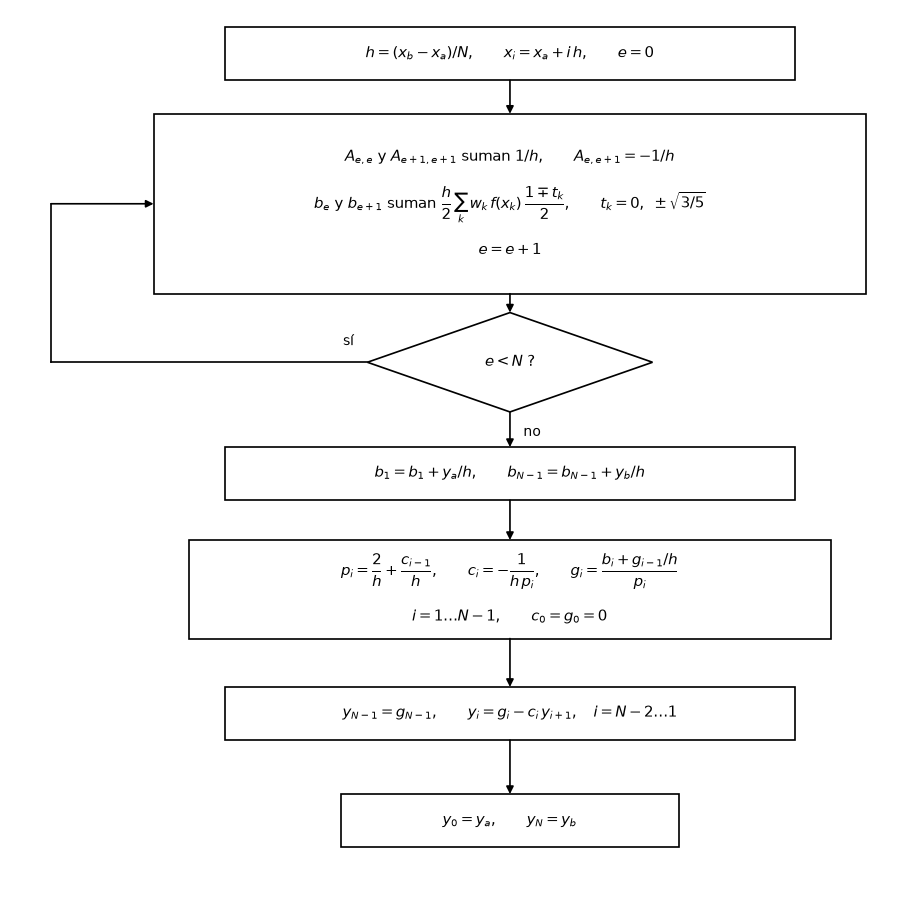

---

# 5. Función general

`fem_1d` resuelve $-y''=f(x)$ en $[x_a,x_b]$ con $y(x_a)=y_a$ y $y(x_b)=y_b$ para cualquier $f$ y
cualquier $N\ge2$. Conserva la estructura del código de clase (malla, matriz por elementos, vector de
carga, fronteras y solución) y aplica los pasos 3 a 11. `evaluar` calcula $y_h(x)$ con las funciones
sombrero del paso 4.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.integrate as integrate

plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.grid": False})

In [2]:
def fem_1d(N, f, xa, xb, ya, yb, fuente="gauss"):
    """Resuelve -y'' = f(x) en [xa, xb] con y(xa) = ya, y(xb) = yb y N >= 2 elementos lineales.

    Con fuente="gauss" el vector de carga se integra con el paso 9; con fuente="nodal", la fuente
    se aproxima por rectas entre nodos (seccion 9). Devuelve los nodos x y los valores y en los nodos.
    """
    h = (xb - xa)/N
    x = np.zeros(N + 1)
    for i in range(N + 1):
        x[i] = xa + i*h

    t_gauss = [-math.sqrt(3.0/5.0), 0.0, math.sqrt(3.0/5.0)]
    w_gauss = [5.0/9.0, 8.0/9.0, 5.0/9.0]

    diagonal = np.zeros(N + 1)
    vecina = np.zeros(N + 1)
    b = np.zeros(N + 1)
    for e in range(N):
        diagonal[e] += 1.0/h
        diagonal[e+1] += 1.0/h
        vecina[e+1] = -1.0/h
        if fuente == "gauss":
            centro = 0.5*(x[e] + x[e+1])
            for k in range(3):
                fk = f(centro + 0.5*h*t_gauss[k])
                b[e] += 0.5*h*w_gauss[k]*fk*(1.0 - t_gauss[k])/2.0
                b[e+1] += 0.5*h*w_gauss[k]*fk*(1.0 + t_gauss[k])/2.0
        else:
            f_e = f(x[e])
            f_siguiente = f(x[e+1])
            b[e] += h*(2.0*f_e + f_siguiente)/6.0
            b[e+1] += h*(f_e + 2.0*f_siguiente)/6.0

    b[1] -= vecina[1]*ya
    b[N-1] -= vecina[N]*yb

    c = np.zeros(N + 1)
    g = np.zeros(N + 1)
    for i in range(1, N):
        pivote = diagonal[i] - vecina[i]*c[i-1]
        if i < N - 1:
            c[i] = vecina[i+1]/pivote
        g[i] = (b[i] - vecina[i]*g[i-1])/pivote

    y = np.zeros(N + 1)
    y[0] = ya
    y[N] = yb
    y[N-1] = g[N-1]
    for i in range(N - 2, 0, -1):
        y[i] = g[i] - c[i]*y[i+1]
    return x, y


def evaluar(x_nodos, y_nodos, x):
    """Valor de y_h(x) = sum_j y_j phi_j(x) en un punto x de [x_0, x_N]."""
    N = len(x_nodos) - 1
    h = x_nodos[1] - x_nodos[0]
    e = int((x - x_nodos[0])/h)
    if e > N - 1:
        e = N - 1
    phi_e = (x_nodos[e+1] - x)/h
    phi_siguiente = (x - x_nodos[e])/h
    return y_nodos[e]*phi_e + y_nodos[e+1]*phi_siguiente

---

# 6. Solución analítica con la función de Green

**Paso 12. Función de Green.** $G(x,s)$ cumple $-\dfrac{\partial^2G}{\partial x^2}=\delta(x-s)$ en
$[0,1]$, con $G(0,s)=G(1,s)=0$. Fuera de $x=s$ la segunda derivada es nula, de modo que $G$ es lineal a
cada lado de $s$; con las condiciones en los extremos,

$$G=\alpha\,x\quad(x<s),\qquad G=\beta\,(1-x)\quad(x>s).$$

La continuidad de $G$ en $x=s$ exige $\alpha\,s=\beta\,(1-s)$. Al integrar la ecuación entre $s^-$ y $s^+$:

$$-\left[\frac{\partial G}{\partial x}\right]_{s^-}^{s^+}=-(-\beta-\alpha)=1\quad\Rightarrow\quad\alpha+\beta=1.$$

De las dos condiciones, $\alpha=1-s$ y $\beta=s$:

$$G(x,s)=\begin{cases}x\,(1-s), & x\le s,\\ s\,(1-x), & x\ge s.\end{cases}$$

**Paso 13. Solución general.** Como $-\dfrac{d^2}{dx^2}\displaystyle\int_0^1G\,f\,ds=\int_0^1\delta(x-s)\,f(s)\,ds=f(x)$
y la integral se anula en $x=0$ y en $x=1$, la solución se obtiene al sumar $(1-x)\,y_a+x\,y_b$, que
satisface las dos condiciones de frontera y tiene segunda derivada nula:

$$y(x)=\int_0^1G(x,s)\,f(s)\,ds+(1-x)\,y_a+x\,y_b
=(1-x)\int_0^x s\,f(s)\,ds+x\int_x^1(1-s)\,f(s)\,ds+(1-x)\,y_a+x\,y_b.$$

**Paso 14. Integrales.** Por partes, $\displaystyle\int s\,e^s\,ds=e^s(s-1)$ y
$\displaystyle\int s^2e^s\,ds=e^s(s^2-2s+2)$. Con $f(s)=s\,e^s$:

$$\int_0^x s^2e^s\,ds=e^x(x^2-2x+2)-2,$$

$$\int_x^1(1-s)\,s\,e^s\,ds=\Big[e^s(s-1)\Big]_x^1-\Big[e^s(s^2-2s+2)\Big]_x^1
=-e^x(x-1)-e+e^x(x^2-2x+2)=e^x(x^2-3x+3)-e.$$

**Paso 15. Suma.** Con $y_a=3-e$ y $y_b=0$:

$$y(x)=(1-x)\big[e^x(x^2-2x+2)-2\big]+x\big[e^x(x^2-3x+3)-e\big]+(1-x)(3-e).$$

El coeficiente de $e^x$ es $(1-x)(x^2-2x+2)+x(x^2-3x+3)=2-x$, y el término restante,
$-2(1-x)-e\,x+(1-x)(3-e)=1-e-x$. Por tanto,

$$y(x)=(2-x)\,e^x+1-e-x=1-e-e^x(x-2)-x,$$

que coincide con la solución del enunciado y cumple $y(0)=3-e$ y $y(1)=0$.

---

# 7. Comparación con la solución analítica

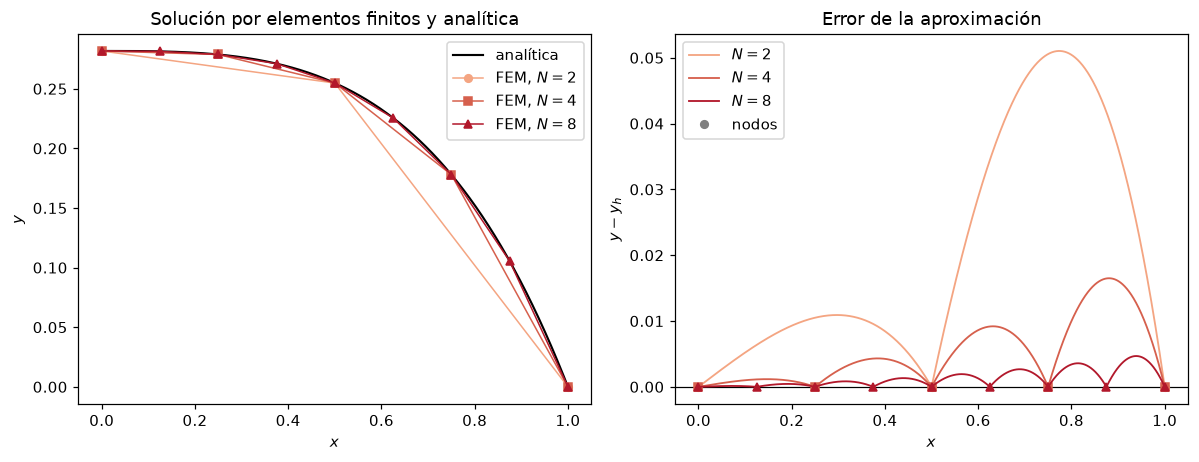

In [3]:
def f(x):
    """Lado derecho de -y'' = f(x)."""
    return x*math.exp(x)


def y_exacta(x):
    """Solucion analitica del paso 15."""
    return 1.0 - math.e - math.exp(x)*(x - 2.0) - x


ya = 3.0 - math.e
yb = 0.0

puntos = 3201
malla_fina = np.zeros(puntos)
exacta_fina = np.zeros(puntos)
for k in range(puntos):
    malla_fina[k] = k/(puntos - 1)
    exacta_fina[k] = y_exacta(malla_fina[k])

colores = {2: "#f4a582", 4: "#d6604d", 8: "#b2182b"}
marcas = {2: "o", 4: "s", 8: "^"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.0, 4.3))

ax1.plot(malla_fina, exacta_fina, color="black", linewidth=1.4, label="analítica")
for N in (2, 4, 8):
    x, y = fem_1d(N, f, 0.0, 1.0, ya, yb)
    ax1.plot(x, y, color=colores[N], marker=marcas[N], markersize=5, linewidth=1.0, label=f"FEM, $N={N}$")
ax1.set_xlabel("$x$")
ax1.set_ylabel("$y$")
ax1.set_title("Solución por elementos finitos y analítica")
ax1.legend()

ax2.axhline(0.0, color="black", linewidth=0.8)
for N in (2, 4, 8):
    x, y = fem_1d(N, f, 0.0, 1.0, ya, yb)
    error = np.zeros(puntos)
    for k in range(puntos):
        error[k] = exacta_fina[k] - evaluar(x, y, malla_fina[k])
    error_en_nodos = np.zeros(N + 1)
    for i in range(N + 1):
        error_en_nodos[i] = y_exacta(x[i]) - y[i]
    ax2.plot(malla_fina, error, color=colores[N], linewidth=1.2, label=f"$N={N}$")
    ax2.plot(x, error_en_nodos, color=colores[N], marker=marcas[N], markersize=5, linestyle="none")
ax2.plot([], [], color="gray", marker="o", markersize=5, linestyle="none", label="nodos")
ax2.set_xlabel("$x$")
ax2.set_ylabel(r"$y-y_h$")
ax2.set_title("Error de la aproximación")
ax2.legend()

fig.tight_layout()
plt.show()

**Paso 16. Error en los nodos.** Si $b$ se integra de forma exacta, $y$ y $y_h$ satisfacen la
ecuación (1) con las mismas $\phi_i$, $i=1,\dots,N-1$. Al restar, el error $\varepsilon=y-y_h$ cumple

$$\int_0^1\varepsilon'\,\phi_i'\,dx=0,\qquad i=1,\dots,N-1,\qquad\varepsilon(0)=\varepsilon(1)=0.$$

Como $G$ es simétrica, $G(x,s)=G(s,x)$, se cumple $-\dfrac{\partial^2G(x_i,s)}{\partial s^2}=\delta(s-x_i)$.
En el nodo $x_i$, la integración por partes da

$$\varepsilon(x_i)=\int_0^1\varepsilon(s)\,\delta(s-x_i)\,ds=-\int_0^1\varepsilon\,\frac{\partial^2G}{\partial s^2}\,ds
=-\Big[\,\varepsilon\,\frac{\partial G}{\partial s}\,\Big]_0^1+\int_0^1\varepsilon'\,\frac{\partial G}{\partial s}\,ds
=\int_0^1\varepsilon'\,\frac{\partial G}{\partial s}\,ds.$$

Como función de $s$, $G(x_i,s)$ es lineal en $[0,x_i]$ y en $[x_i,1]$, se anula en los extremos y solo
cambia de pendiente en el nodo $x_i$; por eso es una combinación de funciones sombrero,
$G(x_i,s)=\sum_{j=1}^{N-1}G(x_i,x_j)\,\phi_j(s)$. Por tanto,

$$\varepsilon(x_i)=\sum_{j=1}^{N-1}G(x_i,x_j)\int_0^1\varepsilon'\,\phi_j'\,ds=0.$$

Los valores nodales coinciden con la solución analítica para cualquier $N$; la única diferencia en los
nodos proviene de la cuadratura del paso 9.

**Paso 17. Error entre nodos.** En el elemento $e$, $y_h$ es la recta que une $y(x_e)$ con $y(x_{e+1})$.
Para un punto $x^*$ del elemento se define

$$F(x)=y(x)-y_h(x)-K\,(x-x_e)(x-x_{e+1}),$$

con $K$ elegido de modo que $F(x^*)=0$. $F$ se anula en $x_e$, $x^*$ y $x_{e+1}$; por el teorema de
Rolle, $F'$ se anula en dos puntos y $F''$ en un punto $\xi$ del elemento. Como $y_h''=0$,
$F''(\xi)=y''(\xi)-2K=0$, y

$$y(x^*)-y_h(x^*)=\frac{y''(\xi)}{2}\,(x^*-x_e)(x^*-x_{e+1}).$$

El factor $|(x-x_e)(x-x_{e+1})|$ alcanza su máximo, $h^2/4$, en el centro del elemento, y
$|y''|=x\,e^x\le e$ en $[0,1]$; por tanto,

$$|y-y_h|\le\frac{e\,h^2}{8}.$$

In [4]:
filas = []
for N in (2, 4, 8, 16, 32, 64):
    x, y = fem_1d(N, f, 0.0, 1.0, ya, yb)
    error_nodos = 0.0
    for i in range(N + 1):
        error_nodos = max(error_nodos, abs(y[i] - y_exacta(x[i])))
    error_maximo = 0.0
    for k in range(puntos):
        error_maximo = max(error_maximo, abs(evaluar(x, y, malla_fina[k]) - exacta_fina[k]))
    h = 1.0/N
    filas.append([N, h, error_nodos, error_maximo, math.e*h*h/8.0])

tabla = pd.DataFrame(filas, columns=["N", "h", "error en nodos", "error maximo", "cota e h^2/8"])
formato = "{:.2e}".format
print(tabla.to_string(index=False, formatters={"h": "{:.5f}".format, "error en nodos": formato,
                                               "error maximo": formato, "cota e h^2/8": formato}))

 N       h error en nodos error maximo cota e h^2/8
 2 0.50000       5.25e-08     5.10e-02     8.49e-02
 4 0.25000       8.30e-10     1.65e-02     2.12e-02
 8 0.12500       1.30e-11     4.68e-03     5.31e-03
16 0.06250       2.05e-13     1.25e-03     1.33e-03
32 0.03125       2.72e-15     3.22e-04     3.32e-04
64 0.01562       2.78e-15     8.17e-05     8.30e-05


En los nodos solo permanece el error de la cuadratura. El error máximo se presenta entre nodos, se
mantiene por debajo de la cota del paso 17 y, al duplicar $N$, se reduce en un factor que tiende a 4,
como corresponde a un error de orden $h^2$.

---

# 8. Comparación con la librería

Corresponde al código de la [sesión 3.1](https://github.com/anferivera/Fisica_Computacional_1/blob/main/Sesiones/PDE/3.1_FEM_finite_element_method.ipynb) escrito como función: matriz $A$
completa, $b$ con `integrate.quad` y solución del sistema con `np.linalg.solve`. Los términos
$A_{i,0}\,y_a$ y $A_{i,N}\,y_b$ se trasladan al lado derecho (paso 6) antes de reemplazar las filas $0$ y
$N$ de $A$ por filas de la identidad.

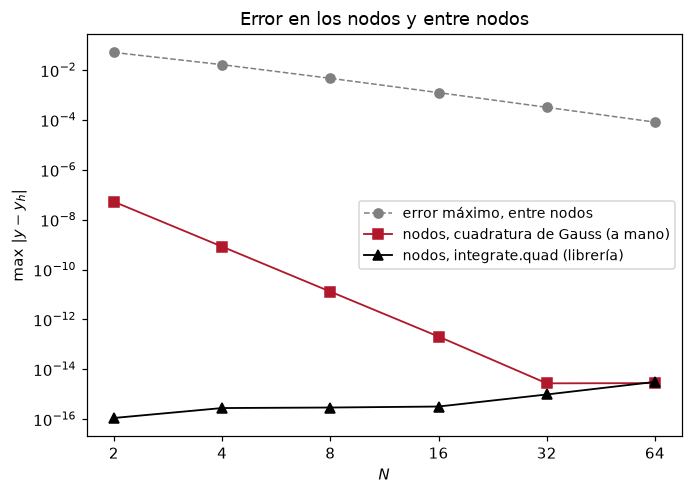

In [5]:
def fem_libreria(N, f, xa, xb, ya, yb):
    """Codigo de clase con A llena, integrate.quad y np.linalg.solve."""
    h = (xb - xa)/N
    xi = np.zeros(N + 1)
    for i in range(N + 1):
        xi[i] = xa + i*h

    A = np.zeros((N + 1, N + 1))
    for i in range(1, N + 1):
        A[i-1, i-1] = A[i-1, i-1] + 1.0/h
        A[i-1, i] = A[i-1, i] - 1.0/h
        A[i, i-1] = A[i-1, i]
        A[i, i] = A[i, i] + 1.0/h

    def lin1(x, x1, x2):
        return (x - x1)/(x2 - x1)

    def lin2(x, x1, x2):
        return (x2 - x)/(x2 - x1)

    def carga1(x, x1, x2):
        return f(x)*lin1(x, x1, x2)

    def carga2(x, x1, x2):
        return f(x)*lin2(x, x1, x2)

    b = np.zeros(N + 1)
    for i in range(1, N + 1):
        b[i-1] = b[i-1] + integrate.quad(carga2, xi[i-1], xi[i], args=(xi[i-1], xi[i]))[0]
        b[i] = b[i] + integrate.quad(carga1, xi[i-1], xi[i], args=(xi[i-1], xi[i]))[0]

    for i in range(1, N):
        b[i] = b[i] - A[i, 0]*ya - A[i, N]*yb
    for j in range(N + 1):
        A[0, j] = 0.0
        A[j, 0] = 0.0
        A[N, j] = 0.0
        A[j, N] = 0.0
    A[0, 0] = 1.0
    A[N, N] = 1.0
    b[0] = ya
    b[N] = yb

    return xi, np.linalg.solve(A, b)


valores_N = [2, 4, 8, 16, 32, 64]
nodos_mano = np.zeros(len(valores_N))
nodos_libreria = np.zeros(len(valores_N))
maximo_entre_nodos = np.zeros(len(valores_N))
for n in range(len(valores_N)):
    N = valores_N[n]
    x, y_mano = fem_1d(N, f, 0.0, 1.0, ya, yb)
    x, y_libreria = fem_libreria(N, f, 0.0, 1.0, ya, yb)
    for i in range(N + 1):
        nodos_mano[n] = max(nodos_mano[n], abs(y_mano[i] - y_exacta(x[i])))
        nodos_libreria[n] = max(nodos_libreria[n], abs(y_libreria[i] - y_exacta(x[i])))
    for k in range(puntos):
        maximo_entre_nodos[n] = max(maximo_entre_nodos[n], abs(evaluar(x, y_mano, malla_fina[k]) - exacta_fina[k]))

fig, ax = plt.subplots(figsize=(6.4, 4.6))
ax.loglog(valores_N, maximo_entre_nodos, color="gray", marker="o", linestyle="--", linewidth=1.0,
          label="error máximo, entre nodos")
ax.loglog(valores_N, nodos_mano, color="#b2182b", marker="s", linewidth=1.2,
          label="nodos, cuadratura de Gauss (a mano)")
ax.loglog(valores_N, nodos_libreria, color="black", marker="^", linewidth=1.2,
          label="nodos, integrate.quad (librería)")
ax.set_xticks(valores_N)
ax.set_xticklabels([str(N) for N in valores_N])
ax.minorticks_off()
ax.set_xlabel("$N$")
ax.set_ylabel(r"$\max\,|y-y_h|$")
ax.set_title("Error en los nodos y entre nodos")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

Con `integrate.quad` el vector $b$ es exacto hasta la precisión de máquina, y los nodos de la librería
difieren de la solución analítica en menos de $4\times10^{-15}$, como establece el paso 16. En la versión a
mano, el error nodal corresponde a la cuadratura de tres puntos: $5.3\times10^{-8}$ con $N=2$, se reduce
unas 64 veces cada vez que se duplica $N$ y, desde $N=32$, queda en el nivel del redondeo, por debajo de
$10^{-14}$. En ambos casos el error en los nodos es varios órdenes de magnitud menor que el error entre
nodos.

---

# 9. Solución con Elmer

En clase le pregunté a usted cómo se vería este problema en un software de elementos finitos como ANSYS.
Para mostrarlo se usó Elmer, un programa libre de elementos finitos
([documentación](https://www.nic.funet.fi/pub/sci/physics/elmer/doc/ElmerModelsManual.pdf)).

En Elmer la ecuación del laboratorio es la de la temperatura en una barra: la fuente de calor es
$x\,e^x$, los extremos están a $T(0)=3-e$ y $T(1)=0$ y los lados están aislados, así que la temperatura
solo cambia a lo largo de $x$. La barra tiene 8 elementos a lo largo, igual que el caso $N=8$ de la
sección 7.

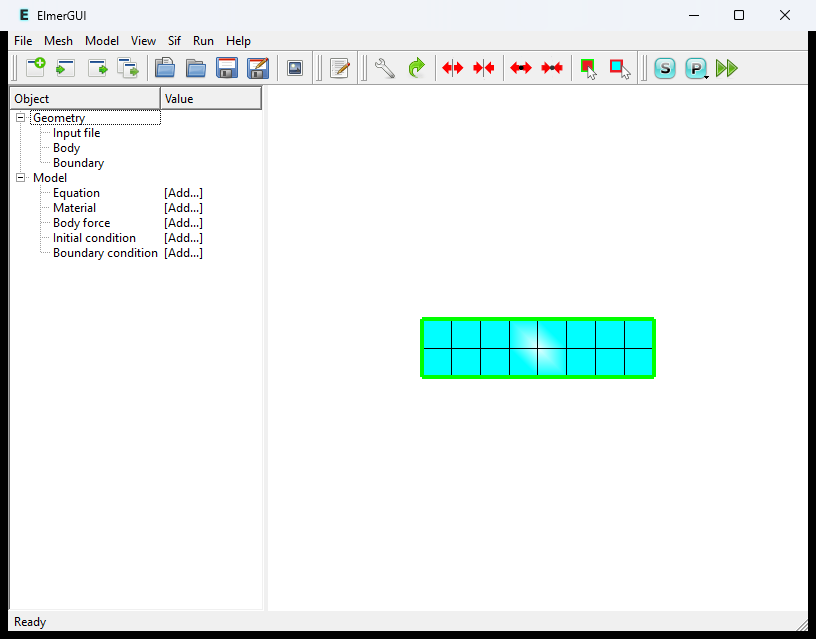

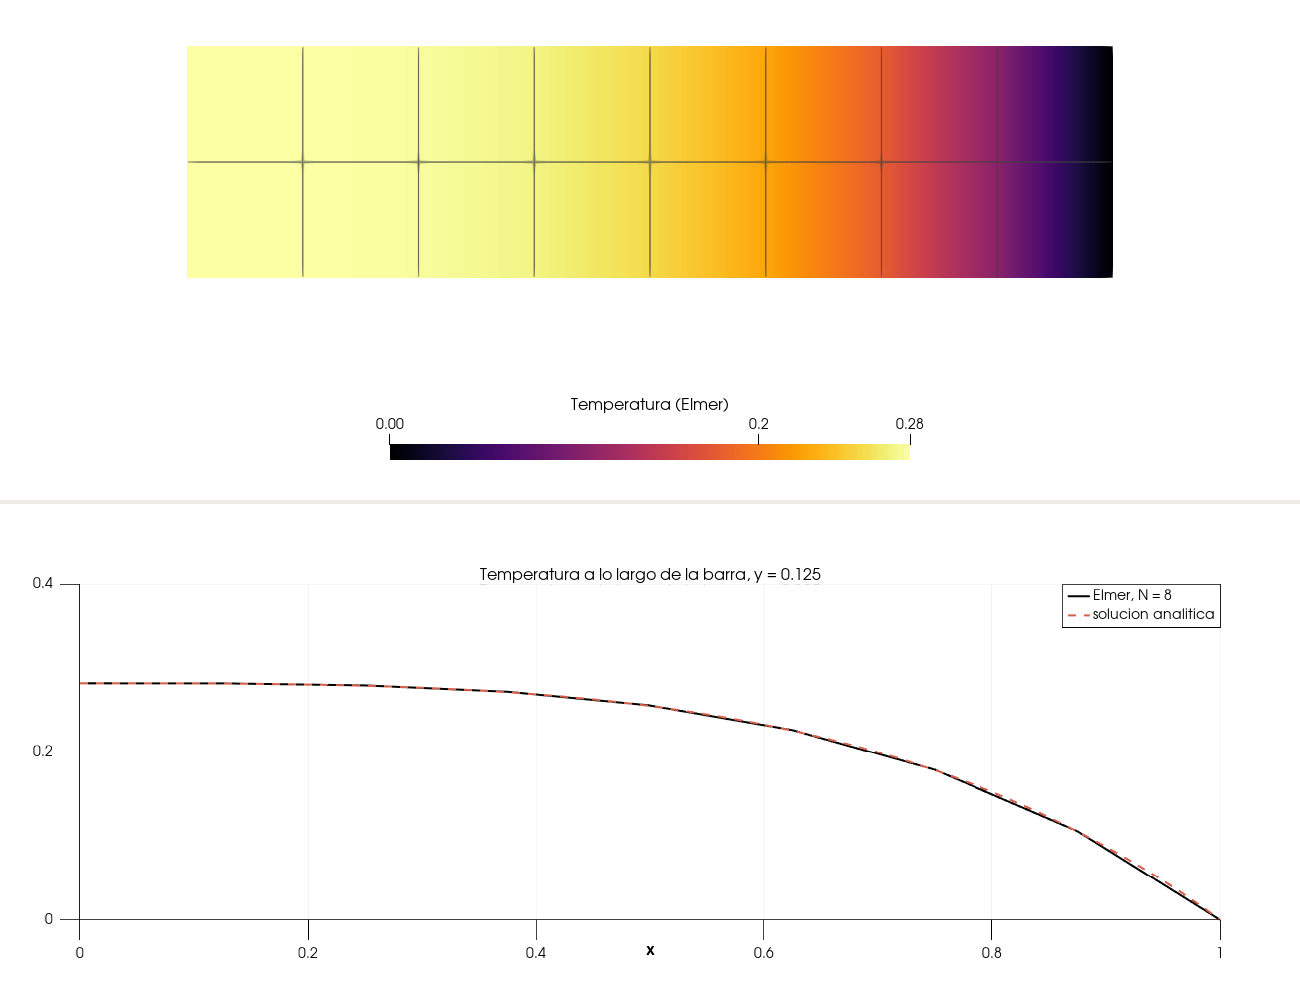

**Comparación con `fem_1d`.** Elmer aproxima la fuente por rectas entre los nodos antes de integrarla,
mientras que `fem_1d` la integra con la cuadratura de Gauss del paso 9. Con `fuente="nodal"`, `fem_1d`
aproxima la fuente igual que Elmer, lo que permite comprobar que la diferencia viene de ahí.

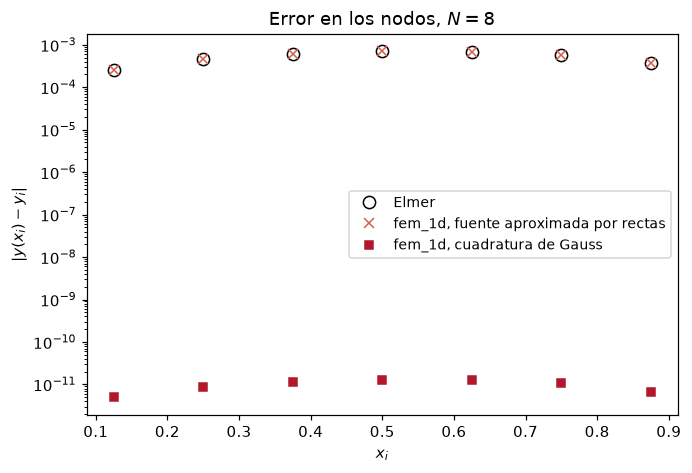

In [6]:
T_elmer = [0.28171817, 0.28162989, 0.27923019, 0.27169693, 0.25549738,
           0.22624908, 0.17855619, 0.10581728, 0.0]

x, y_gauss = fem_1d(8, f, 0.0, 1.0, ya, yb)
x, y_nodal = fem_1d(8, f, 0.0, 1.0, ya, yb, fuente="nodal")

error_elmer = []
error_nodal = []
error_gauss = []
for i in range(1, 8):
    exacta = y_exacta(x[i])
    error_elmer.append(abs(T_elmer[i] - exacta))
    error_nodal.append(abs(y_nodal[i] - exacta))
    error_gauss.append(abs(y_gauss[i] - exacta))

fig, ax = plt.subplots(figsize=(6.4, 4.4))
ax.semilogy(x[1:8], error_elmer, color="black", marker="o", markersize=8, linestyle="none",
            fillstyle="none", label="Elmer")
ax.semilogy(x[1:8], error_nodal, color="#d6604d", marker="x", markersize=7, linestyle="none",
            label="fem_1d, fuente aproximada por rectas")
ax.semilogy(x[1:8], error_gauss, color="#b2182b", marker="s", markersize=5, linestyle="none",
            label="fem_1d, cuadratura de Gauss")
ax.set_xlabel("$x_i$")
ax.set_ylabel(r"$|y(x_i)-y_i|$")
ax.set_title("Error en los nodos, $N=8$")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

En los nodos, Elmer queda a unas $7\times10^{-4}$ de la solución analítica y `fem_1d` a unas $10^{-11}$.
Con la fuente aproximada por rectas, `fem_1d` da los mismos valores que Elmer.

---

## Referencias

- Material del curso: [`Sesiones/PDE/3.1_FEM_finite_element_method.ipynb`](https://github.com/anferivera/Fisica_Computacional_1/blob/main/Sesiones/PDE/3.1_FEM_finite_element_method.ipynb), para la
  forma débil, las funciones sombrero, la matriz de rigidez, las condiciones de Dirichlet, la cuadratura
  gaussiana y el código de clase.
- *Elmer Models Manual*, CSC – IT Center for Science (2026), capítulo 1, *Heat Equation*.